# Time-Series Forecasting with ARIMA / SARIMA

## Project Overview

This project develops an end-to-end time-series forecasting pipeline for analyzing historical demand patterns and generating future demand predictions.

The analysis covers:

- Historical demand trends
- Time-series decomposition
- Seasonality analysis
- Stationarity testing using the Augmented Dickey-Fuller (ADF) test
- Differencing
- ARIMA / SARIMA model selection
- Forecast evaluation using MAPE and RMSE
- 30-day future demand forecasting

### Dataset

The dataset contains daily demand observations along with marketing-event and holiday indicators.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Dataset

In [3]:
DATA_PATH = "../data/daily-demand-series.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


## 2. Initial Data Inspection

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (30, 4)

Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   date             30 non-null     str  
 1   demand           30 non-null     int64
 2   marketing_event  30 non-null     int64
 3   holiday          30 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.1 KB
None

Missing Values:
date               0
demand             0
marketing_event    0
holiday            0
dtype: int64

Duplicate Rows: 0


In [5]:
df.describe()

,demand,marketing_event,holiday
count,30.000000,30.000000,30.000000
mean,142.100000,0.266667,0.133333
std,13.839848,0.449776,0.345746
min,118.000000,0.000000,0.000000
25%,132.500000,0.000000,0.000000
50%,142.000000,0.000000,0.000000
75%,150.250000,0.750000,0.000000
max,174.000000,1.000000,1.000000


## 3. DateTime Preprocessing

In [6]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df = df.set_index("date")

df.head()

,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0


In [7]:
print("Start Date:", df.index.min())
print("End Date:", df.index.max())
print("Frequency:", pd.infer_freq(df.index))

Start Date: 2026-06-01 00:00:00
End Date: 2026-06-30 00:00:00
Frequency: D


In [8]:
df[["demand", "marketing_event", "holiday"]].head(10)

,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0
2026-06-06,151,1,0
2026-06-07,143,0,1
2026-06-08,126,0,0
2026-06-09,129,0,0


In [9]:
print(df.index.is_monotonic_increasing)

True


## 4. Historical Demand Trend

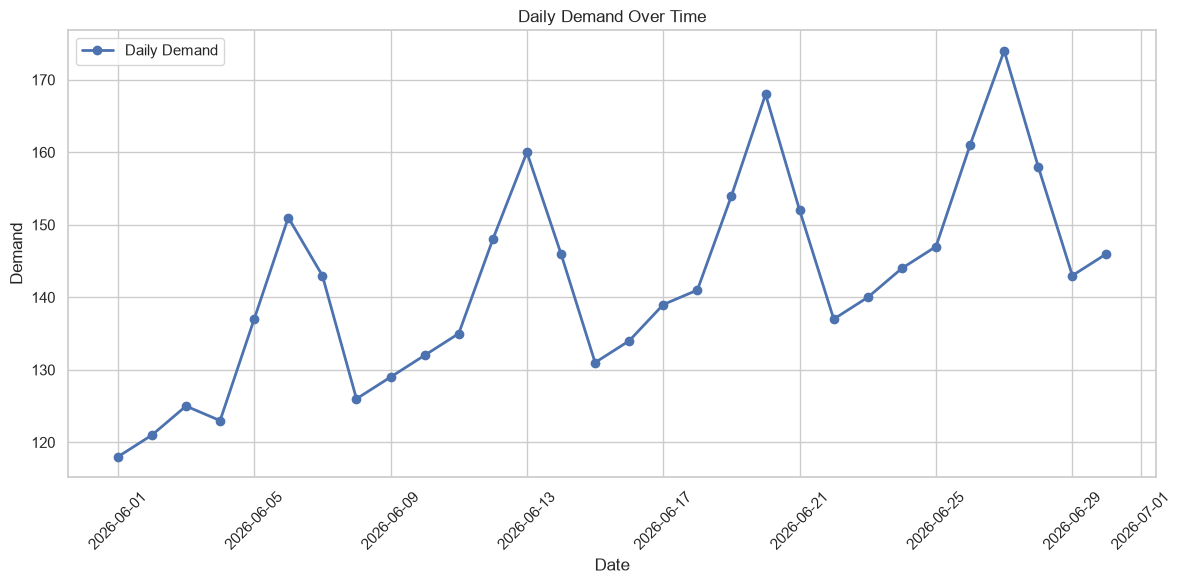

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["demand"],
    marker="o",
    linewidth=2,
    label="Daily Demand"
)

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 5. Trend Analysis

A rolling mean is used to smooth short-term fluctuations and reveal the underlying demand trend.

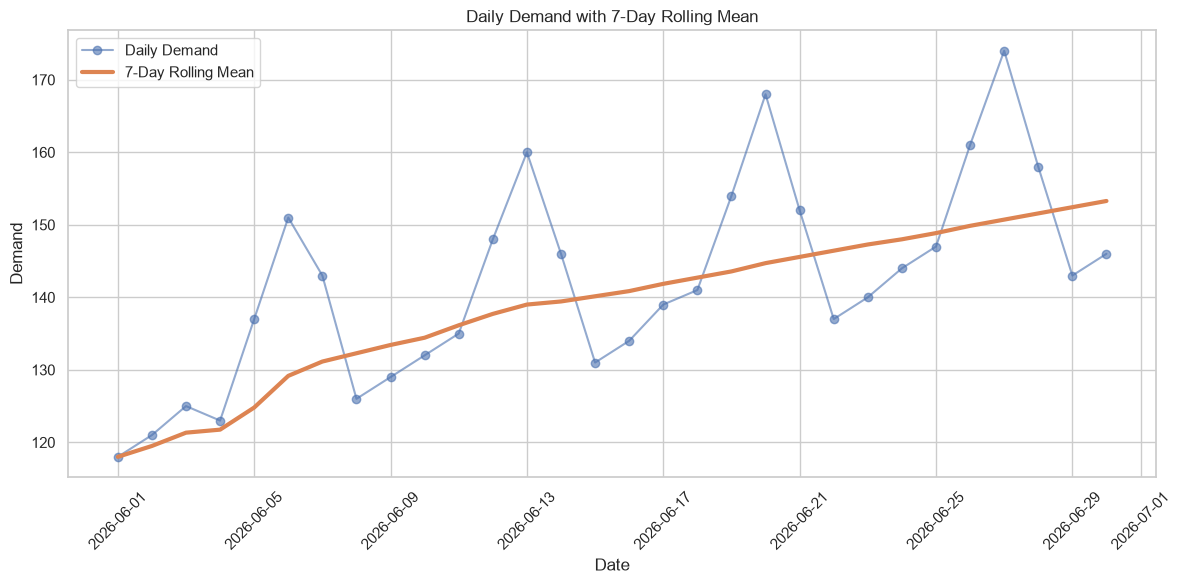

In [11]:
rolling_window = 7

df["rolling_mean_7d"] = df["demand"].rolling(
    window=rolling_window,
    min_periods=1
).mean()

plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["demand"],
    marker="o",
    alpha=0.6,
    label="Daily Demand"
)

plt.plot(
    df.index,
    df["rolling_mean_7d"],
    linewidth=3,
    label="7-Day Rolling Mean"
)

plt.title("Daily Demand with 7-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Weekly Seasonality Analysis

Daily demand is grouped by day of the week to identify potential weekly seasonal patterns.

In [12]:
df["day_of_week"] = df.index.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_pattern = (
    df.groupby("day_of_week")["demand"]
    .mean()
    .reindex(weekday_order)
)

weekly_pattern

day_of_week
Monday       131.00
Tuesday      134.00
Wednesday    135.00
Thursday     136.50
Friday       150.00
Saturday     163.25
Sunday       149.75
Name: demand, dtype: float64

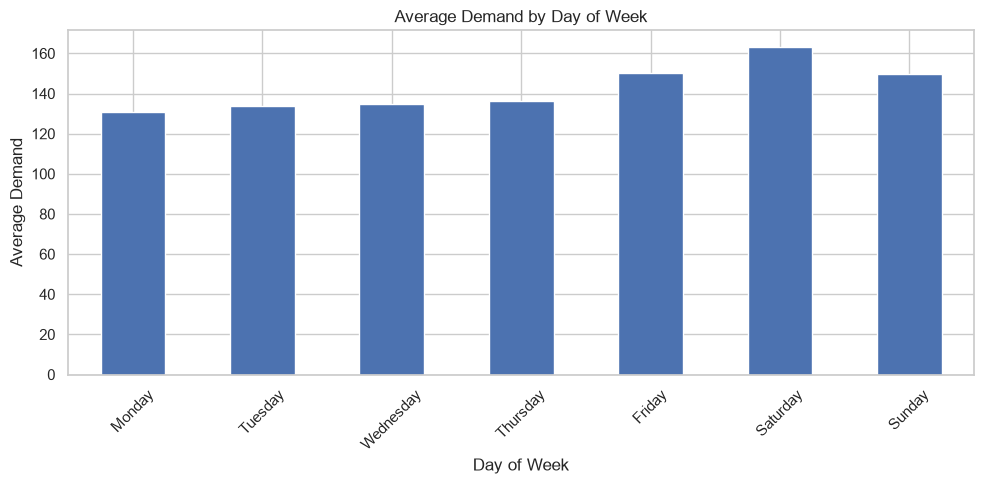

In [13]:
plt.figure(figsize=(10, 5))

weekly_pattern.plot(
    kind="bar",
    rot=45
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.tight_layout()
plt.show()

## 7. Demand During Marketing Events

The effect of marketing events on demand is explored by comparing event and non-event days.

In [14]:
event_demand = (
    df.groupby("marketing_event")["demand"]
    .agg(["count", "mean", "min", "max"])
)

event_demand

,count,mean,min,max
marketing_event,,,,
0,22,136.818182,118,158
1,8,156.625000,137,174


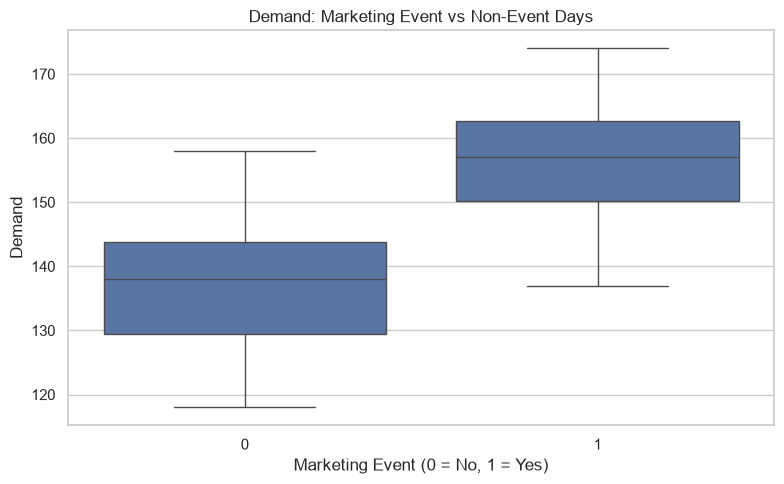

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="marketing_event",
    y="demand"
)

plt.title("Demand: Marketing Event vs Non-Event Days")
plt.xlabel("Marketing Event (0 = No, 1 = Yes)")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

## 8. Time-Series Decomposition

The demand series is decomposed into:

- Observed component
- Trend component
- Seasonal component
- Residual component

A weekly period of 7 days is used because the observations are daily.

In [16]:
demand_series = df["demand"].asfreq("D")

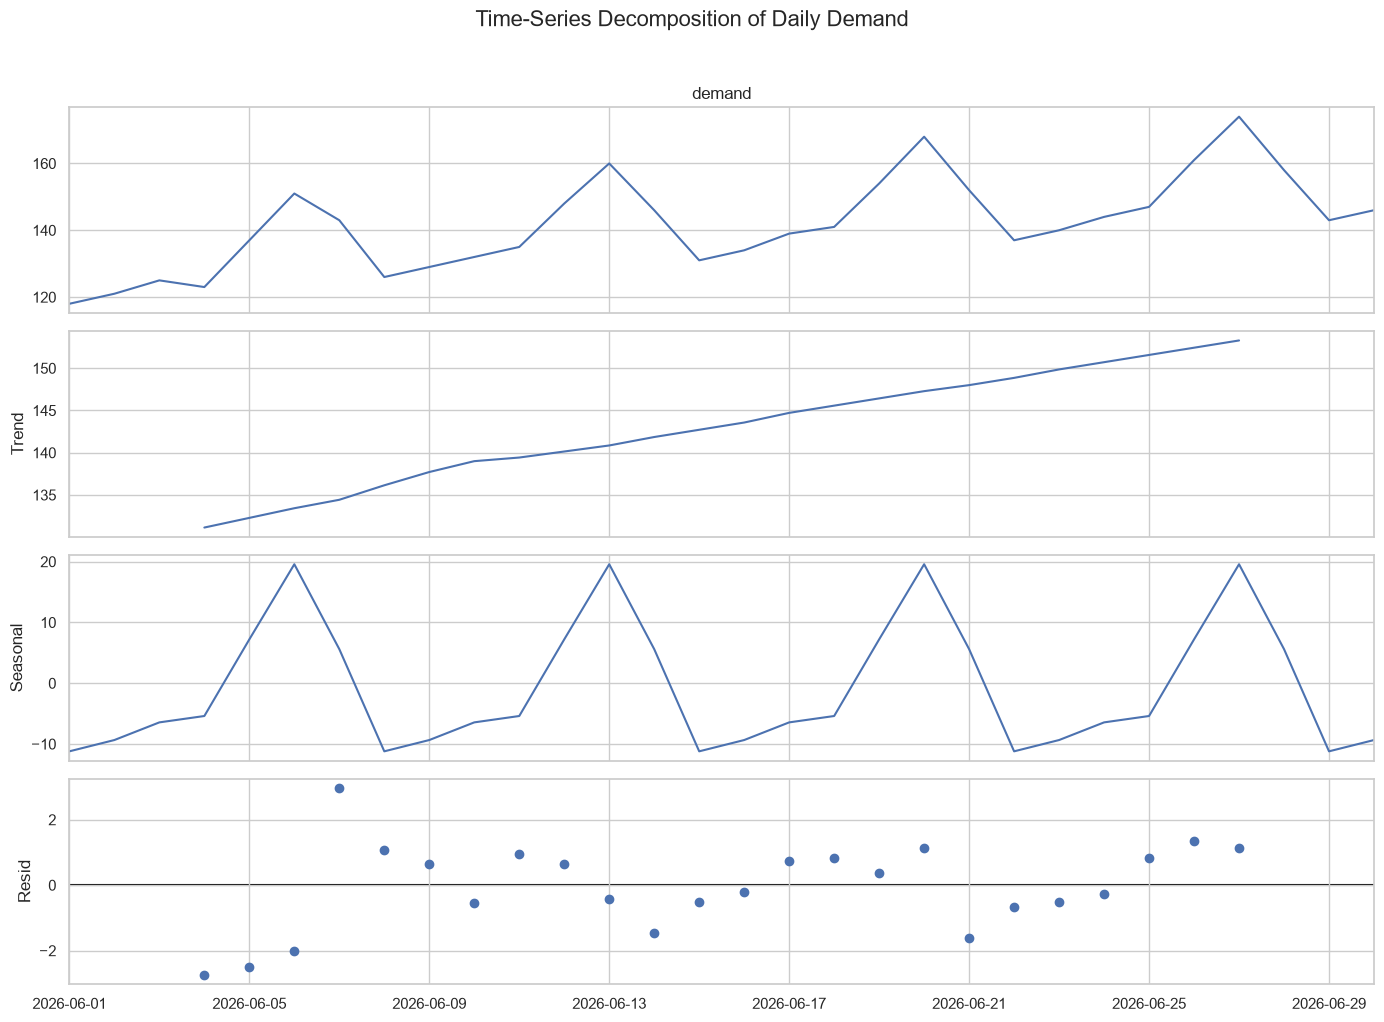

In [17]:
decomposition = seasonal_decompose(
    demand_series,
    model="additive",
    period=7
)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

fig.suptitle(
    "Time-Series Decomposition of Daily Demand",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [18]:
decomposition_components = pd.DataFrame({
    "Observed": decomposition.observed,
    "Trend": decomposition.trend,
    "Seasonal": decomposition.seasonal,
    "Residual": decomposition.resid
})

decomposition_components.head(10)

,Observed,Trend,Seasonal,Residual
date,,,,
2026-06-01,118.0,NaN,-11.204082,NaN
2026-06-02,121.0,NaN,-9.346939,NaN
2026-06-03,125.0,NaN,-6.442177,NaN
2026-06-04,123.0,131.142857,-5.394558,-2.748299
2026-06-05,137.0,132.285714,7.212585,-2.498299
2026-06-06,151.0,133.428571,19.569728,-1.998299
2026-06-07,143.0,134.428571,5.605442,2.965986
2026-06-08,126.0,136.142857,-11.204082,1.061224
2026-06-09,129.0,137.714286,-9.346939,0.632653


In [19]:
decomposition_components.describe()

,Observed,Trend,Seasonal,Residual
count,30.000000,24.000000,30.000000,24.000000
mean,142.100000,142.976190,-0.685034,-0.034014
std,13.839848,6.634275,10.502025,1.354443
min,118.000000,131.142857,-11.204082,-2.748299
25%,132.500000,138.678571,-9.346939,-0.581633
50%,142.000000,143.142857,-5.394558,0.067177
75%,150.250000,148.214286,6.810799,0.858844
max,174.000000,153.285714,19.569728,2.965986


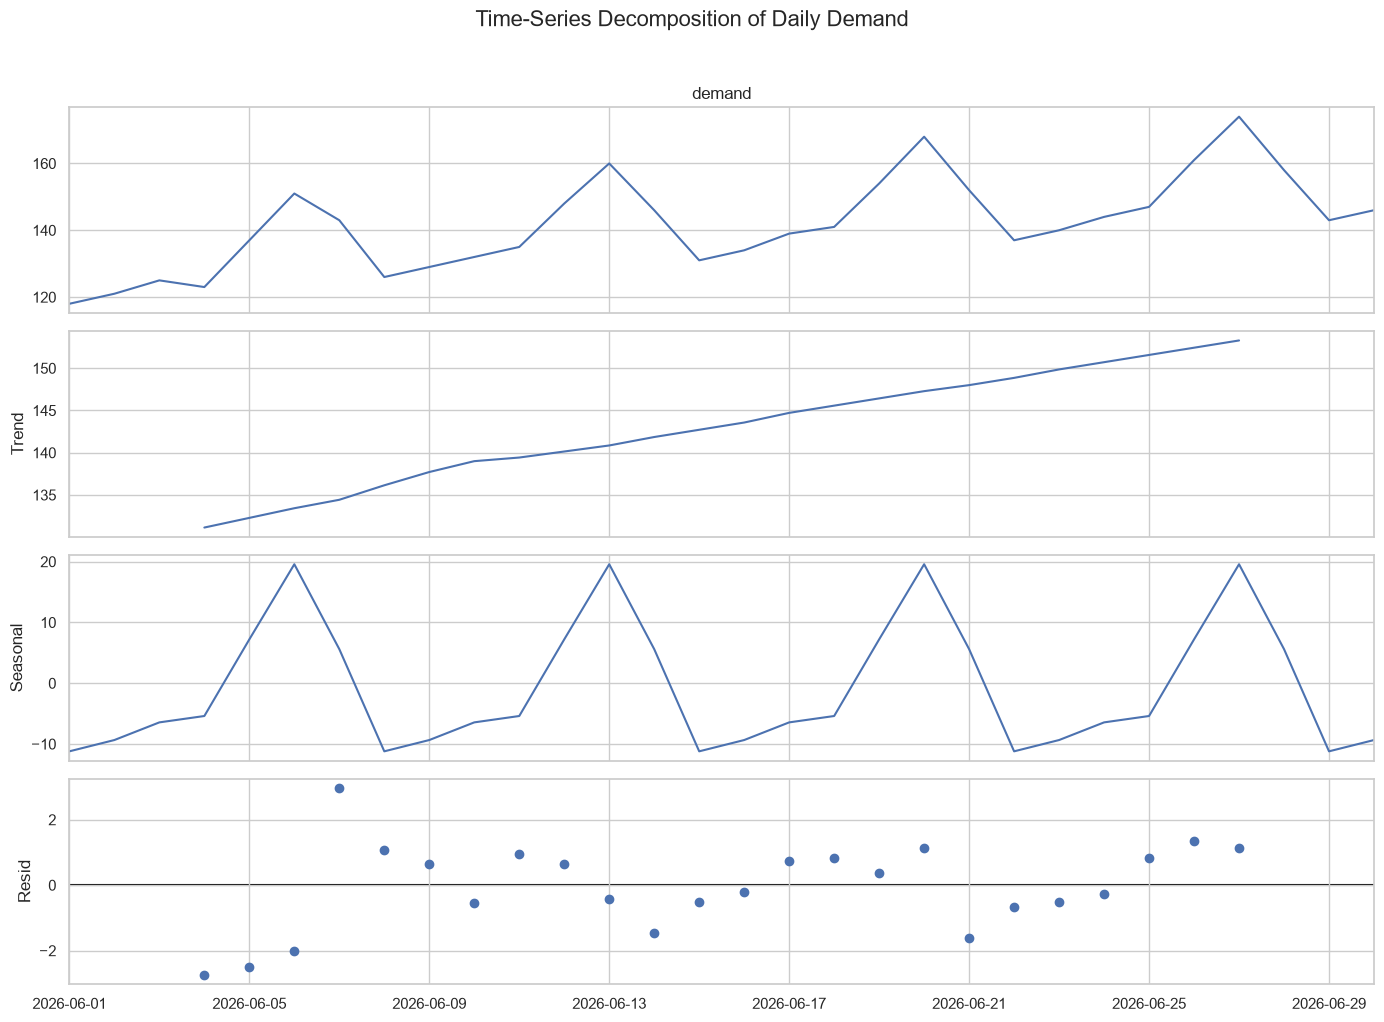

In [20]:
fig = decomposition.plot()

fig.set_size_inches(14, 10)

fig.suptitle(
    "Time-Series Decomposition of Daily Demand",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "../outputs/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()